# Parameter Impact Test — SpeedFactor

Visualizes how different `speedFactor` values affect simulation accuracy for each traffic data point.

Each data point gets its own chart showing:
- **Default**: error at speedFactor = 1.0 (SUMO default)
- **Best**: minimum error across all tested speedFactor values
- **Worst**: maximum error across all tested speedFactor values

## Instructions
1. Run `param_impact_test.py` first to generate results
2. Adjust `CSV_PATH` below if needed
3. Run all cells

In [1]:
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# Auto-find latest param_impact CSV, or set manually
LOG_DIR = os.path.join("..", "testing", "logs")
csv_files = sorted(glob.glob(os.path.join(LOG_DIR, "param_impact_*.csv")))

if csv_files:
    CSV_PATH = csv_files[-1]
else:
    CSV_PATH = os.path.join(LOG_DIR, "param_impact.csv")

print(f"Using: {CSV_PATH}")

Using: ..\testing\logs\param_impact_2026-07-27_01-54-04.csv


In [3]:
df = pd.read_csv(CSV_PATH)
df["abs_error"] = (df["error_north_pct"].abs() + df["error_south_pct"].abs()) / 2

print(f"Loaded {len(df)} rows, {df['data_label'].nunique()} data points, "
      f"{df['speedFactor'].nunique()} speedFactor values")
df.head()

Loaded 420 rows, 28 data points, 15 speedFactor values


,data_label,sl,spt,ul,upt,speedFactor,lcCooperative,lcAssertive,sim_north,sim_south,sim_north_hourly,sim_south_hourly,expected_north_hourly,expected_south_hourly,error_north_pct,error_south_pct,abs_error
0,Senin Pagi,390,204,384,36,0.3,1.0,1.0,64,87,384.0,522.0,426,588,-9.86,-11.22,10.540
1,Senin Siang,780,342,960,60,0.3,1.0,1.0,90,151,540.0,906.0,840,1302,-35.71,-30.41,33.060
2,Senin Sore,684,336,1032,36,0.3,1.0,1.0,72,156,432.0,936.0,720,1368,-40.00,-31.58,35.790
3,Senin Malam,762,210,480,48,0.3,1.0,1.0,120,84,720.0,504.0,810,690,-11.11,-26.96,19.035
4,Selasa Pagi,756,276,1086,114,0.3,1.0,1.0,100,160,600.0,960.0,870,1362,-31.03,-29.52,30.275


## Summary

In [ ]:
summary_rows = []
for label in df["data_label"].unique():
    subset = df[df["data_label"] == label]
    default_row = subset[subset["speedFactor"] == 1.0]
    if default_row.empty:
        continue
    summary_rows.append({
        "label": label,
        "default_error": default_row["abs_error"].values[0],
        "min_error": subset["abs_error"].min(),
        "max_error": subset["abs_error"].max(),
        "best_sf": subset.loc[subset["abs_error"].idxmin(), "speedFactor"],
        "worst_sf": subset.loc[subset["abs_error"].idxmax(), "speedFactor"],
    })

summary = pd.DataFrame(summary_rows)
summary["improvement"] = summary["default_error"] - summary["min_error"]
print(f"Summary for {len(summary)} data points")

## Overview: All Data Points

In [ ]:
fig, ax = plt.subplots(figsize=(22, 6))
x = np.arange(len(summary))

ax.scatter(x, summary["default_error"], color="steelblue", s=50, zorder=3)
ax.set_xlabel("Data Point", fontsize=12)
ax.set_ylabel("Absolute Error (%)", fontsize=12)
ax.set_title("Default speedFactor (=1.0) — Absolute Error per Data Point",
             fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(summary["label"], rotation=45, ha="right", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(22, 6))
x = np.arange(len(summary))

ax.scatter(x, summary["max_error"], color="crimson", s=50, zorder=3)
ax.set_xlabel("Data Point", fontsize=12)
ax.set_ylabel("Absolute Error (%)", fontsize=12)
ax.set_title("Worst speedFactor — Maximum Absolute Error per Data Point",
             fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(summary["label"], rotation=45, ha="right", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(22, 6))
x = np.arange(len(summary))

ax.scatter(x, summary["min_error"], color="green", s=50, zorder=3)
ax.set_xlabel("Data Point", fontsize=12)
ax.set_ylabel("Absolute Error (%)", fontsize=12)
ax.set_title("Best speedFactor — Minimum Absolute Error per Data Point",
             fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(summary["label"], rotation=45, ha="right", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Per-Data-Point Charts: Default vs Best vs Worst Error

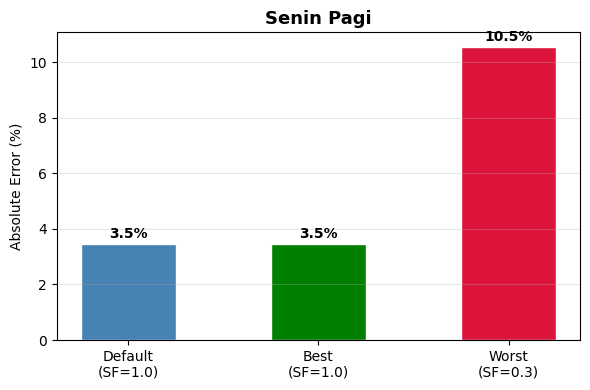

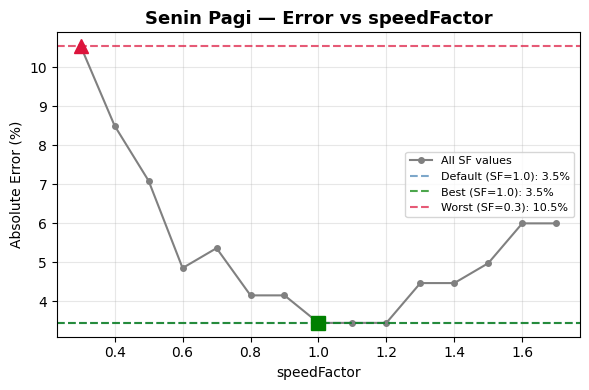

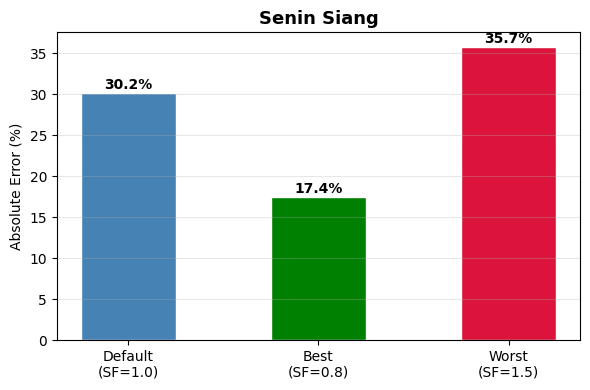

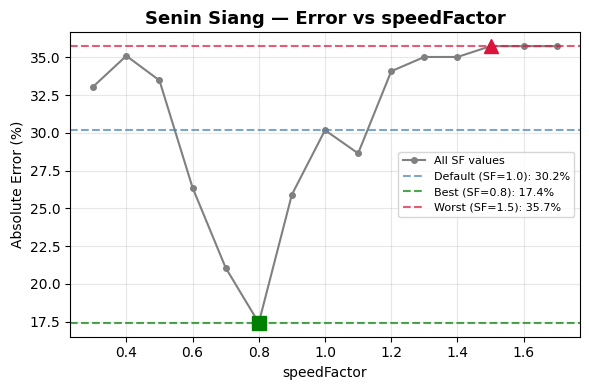

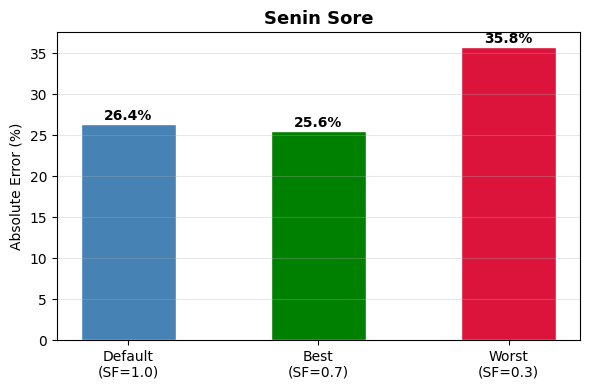

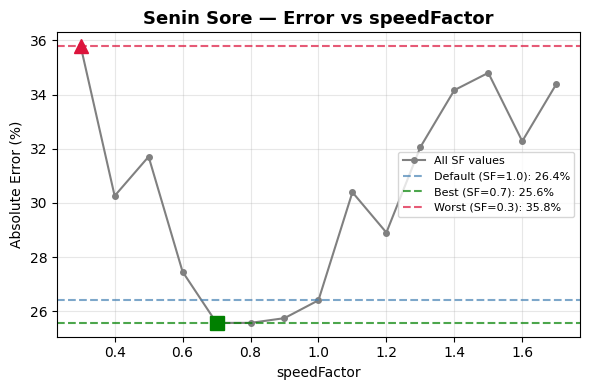

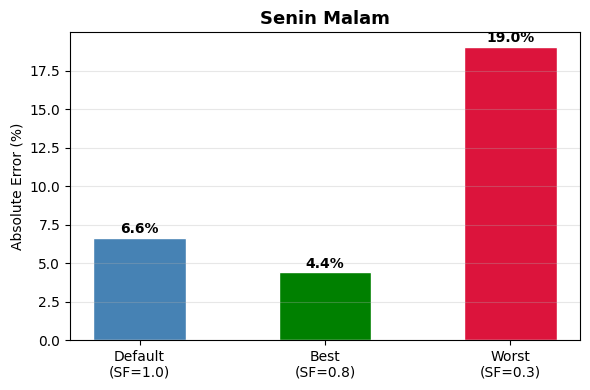

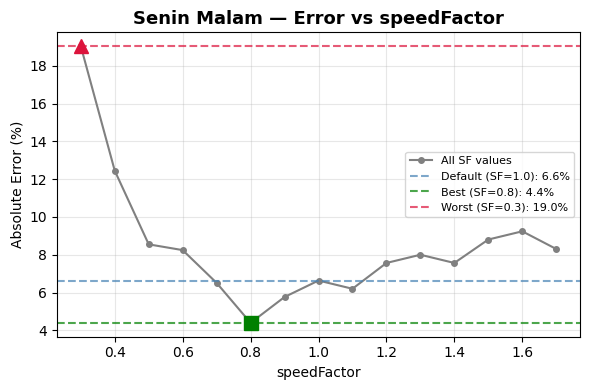

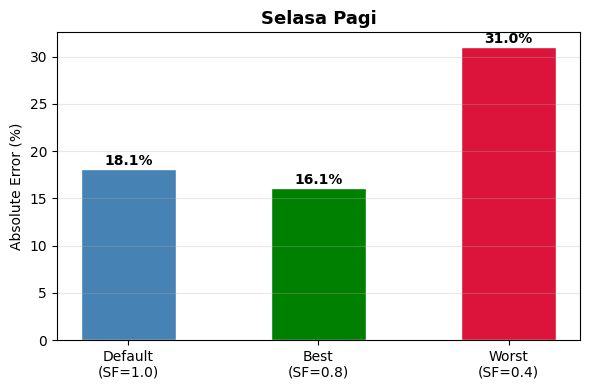

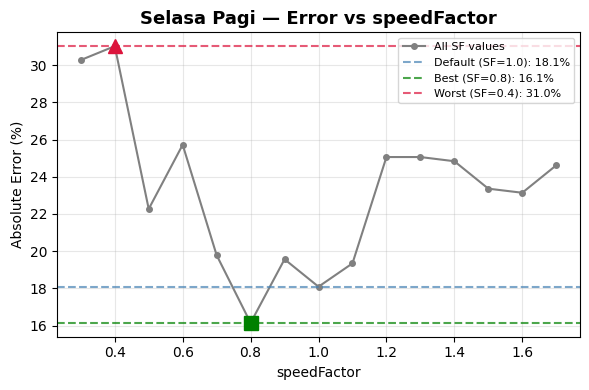

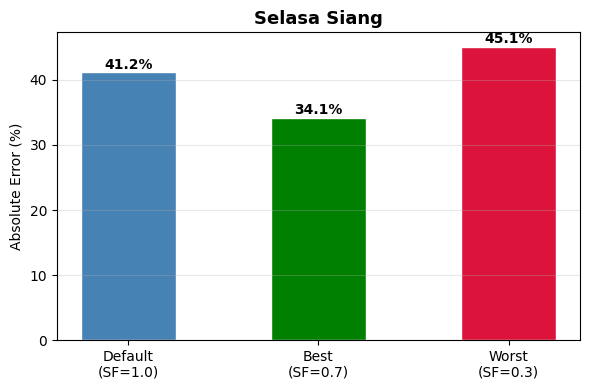

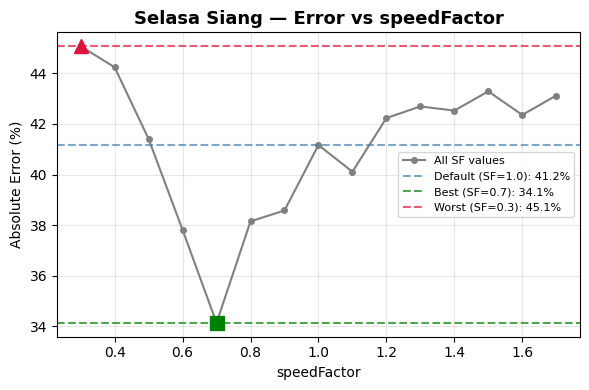

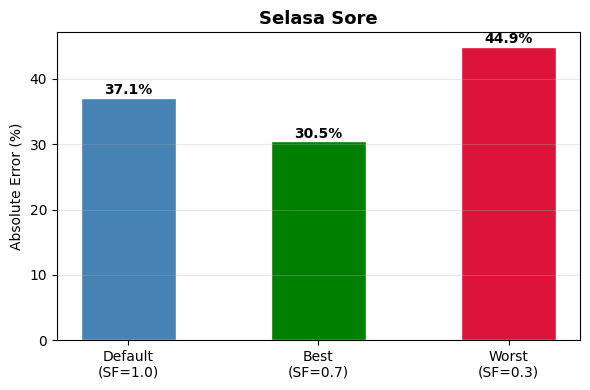

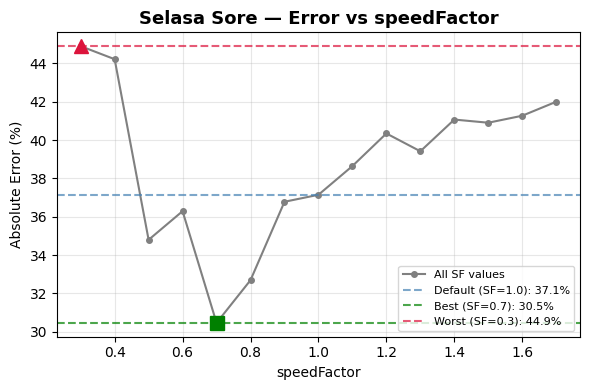

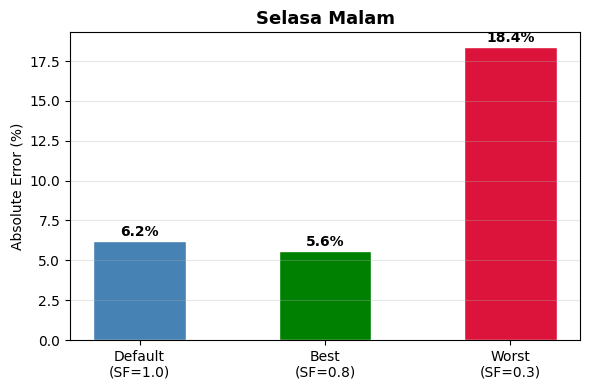

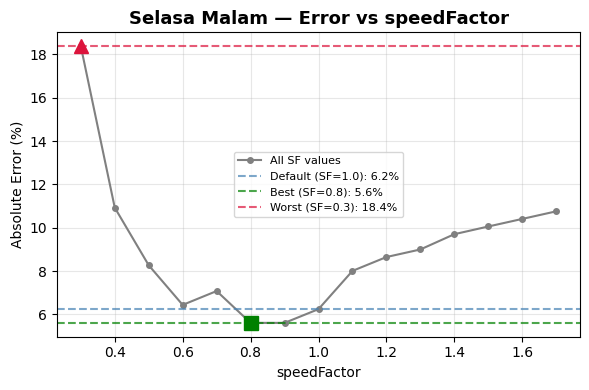

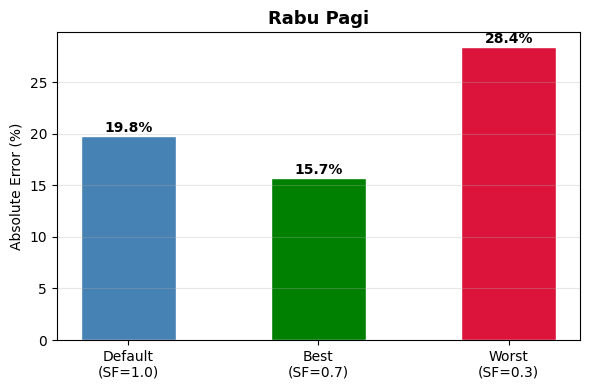

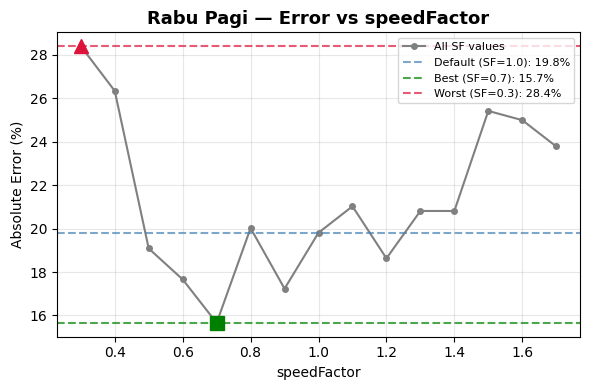

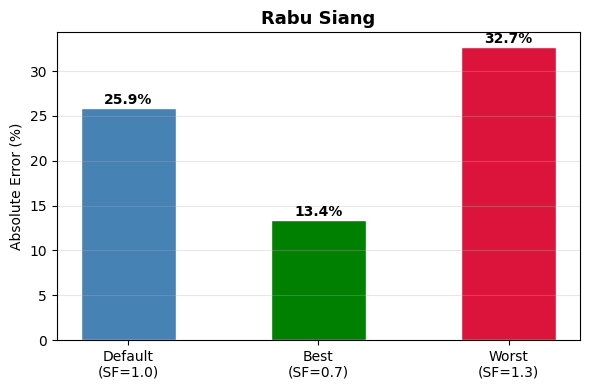

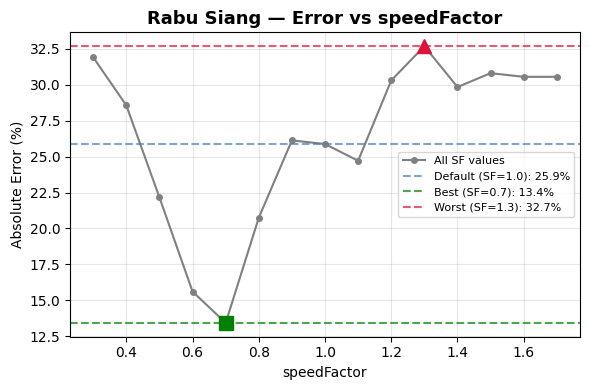

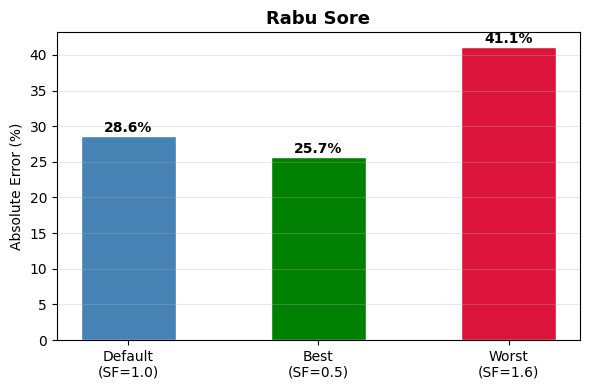

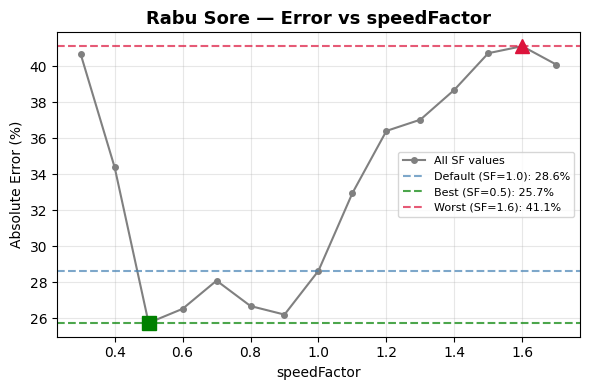

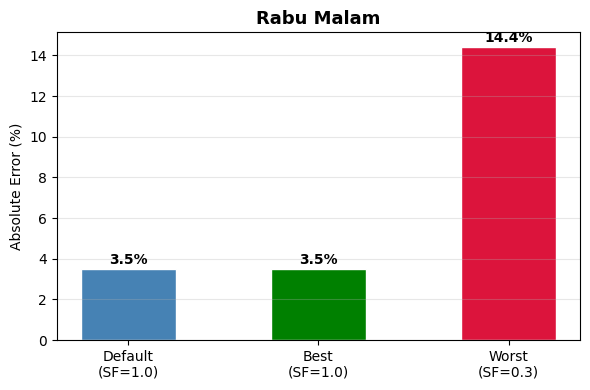

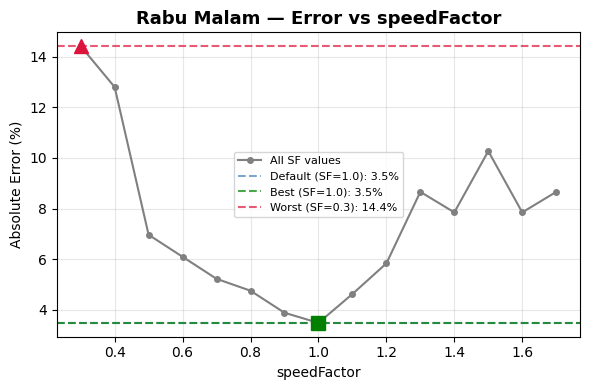

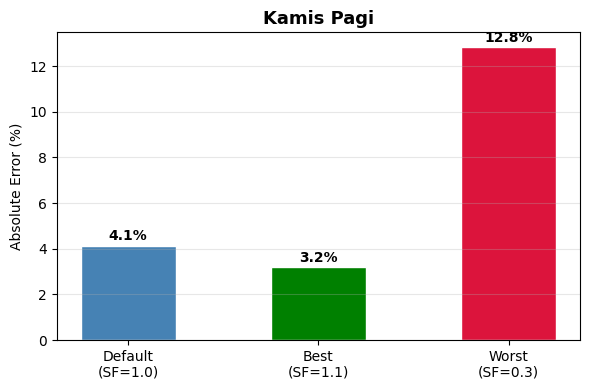

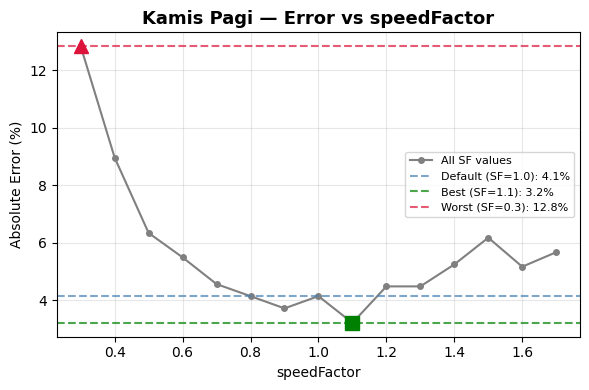

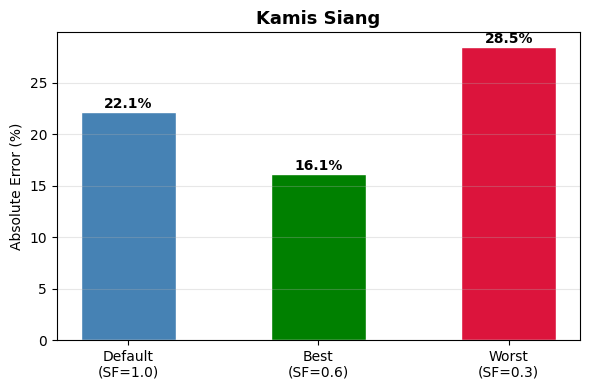

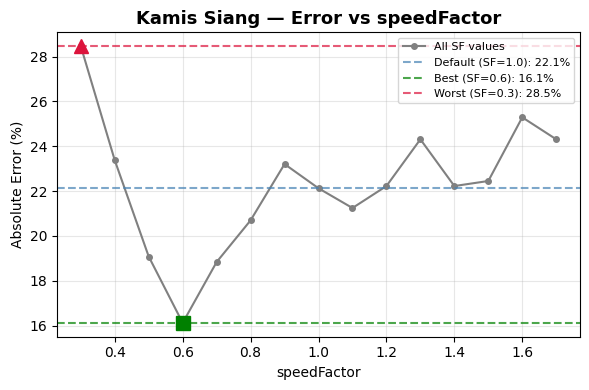

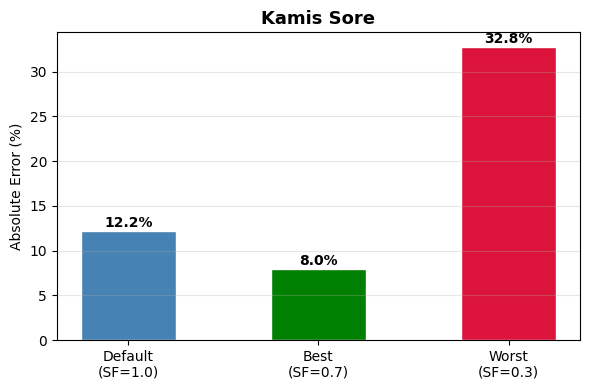

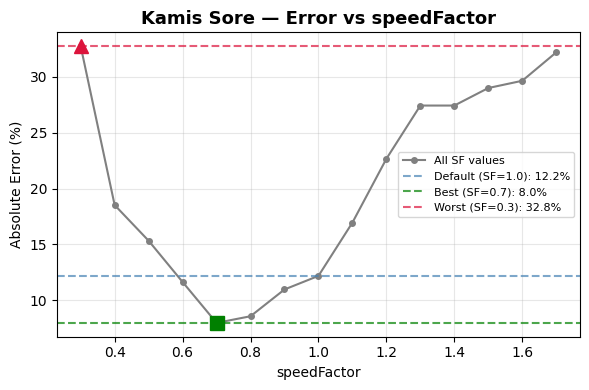

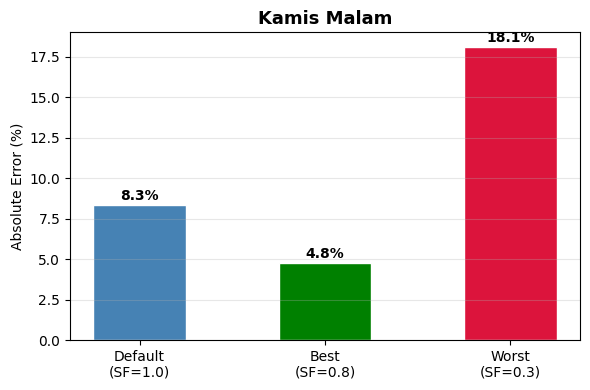

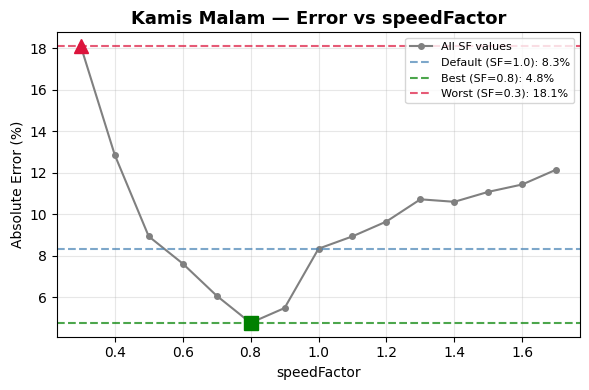

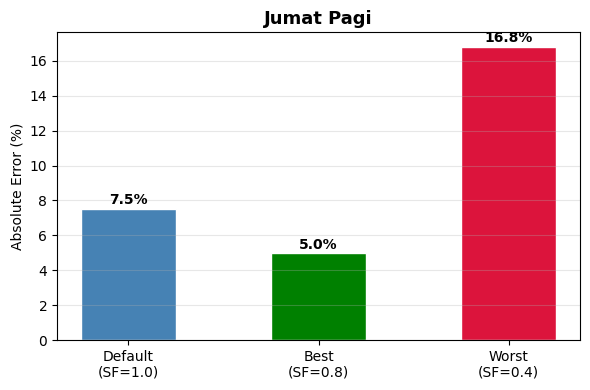

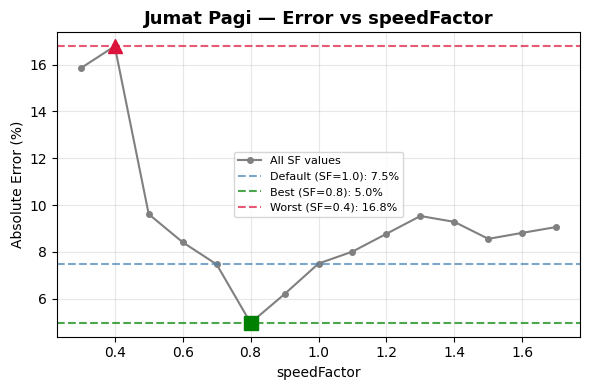

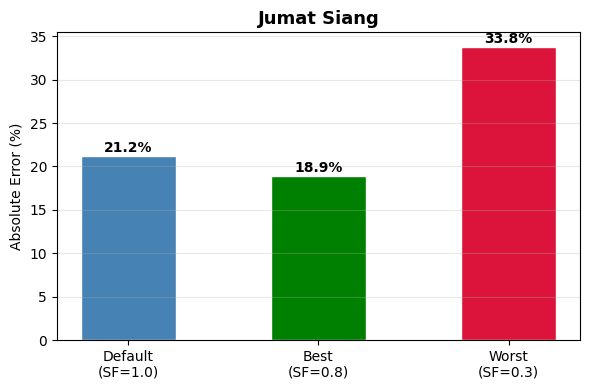

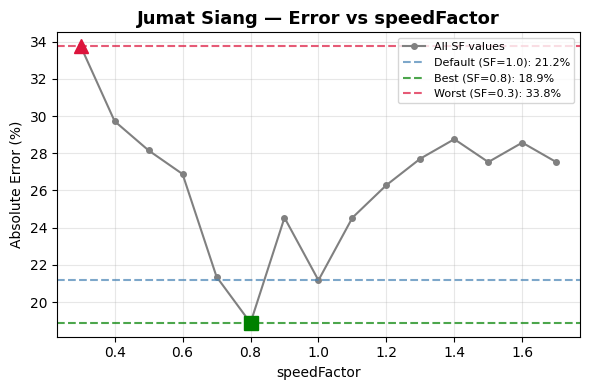

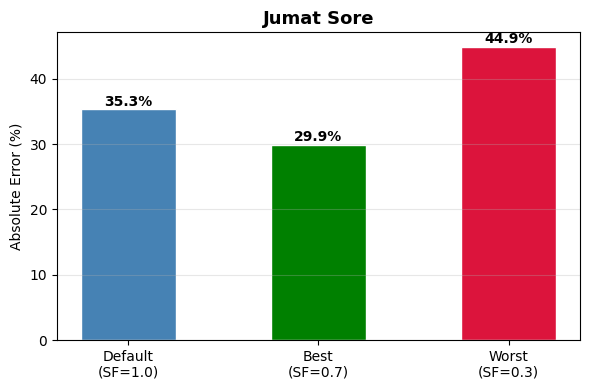

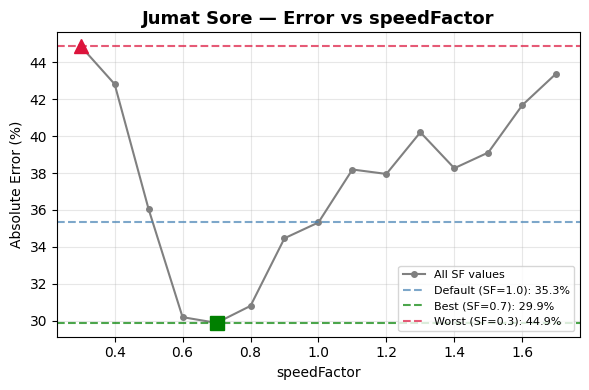

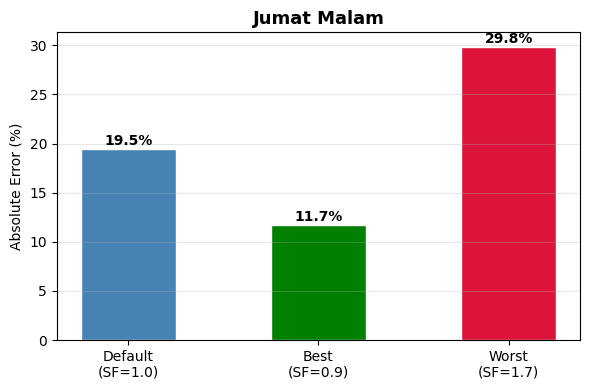

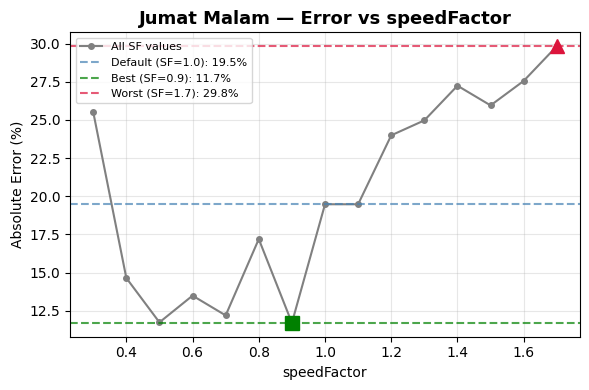

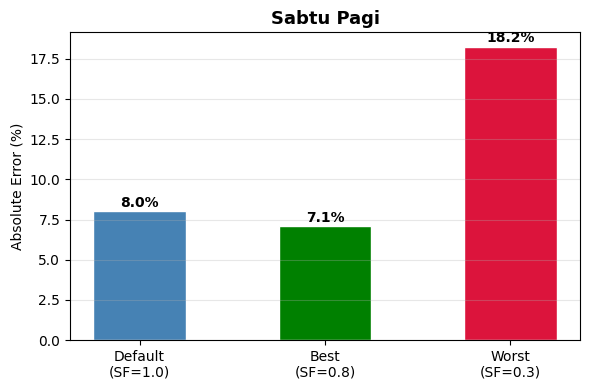

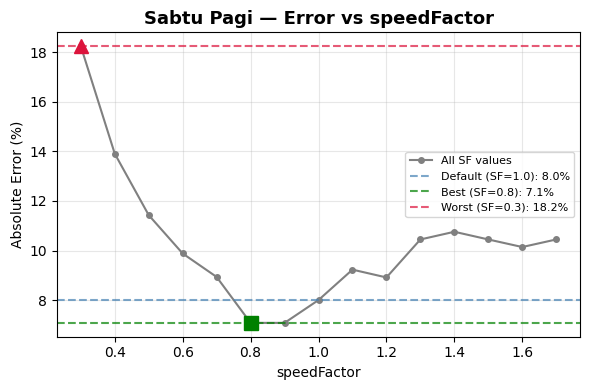

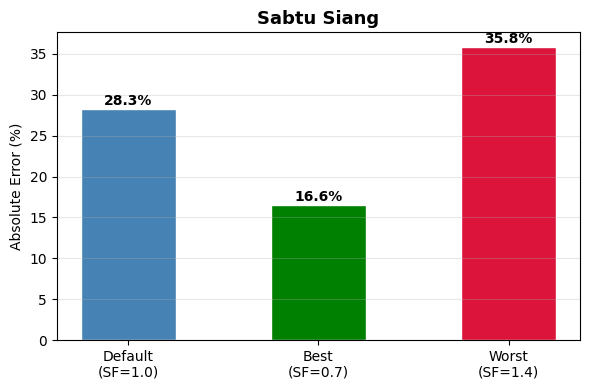

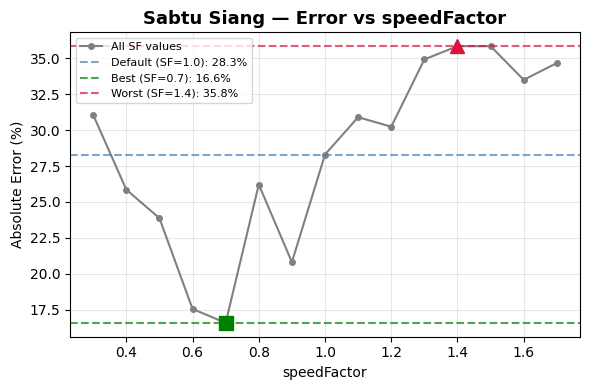

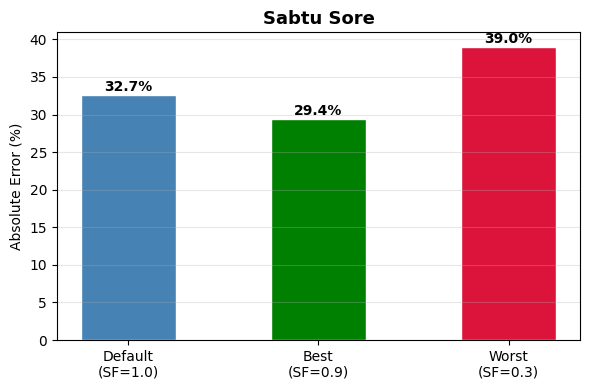

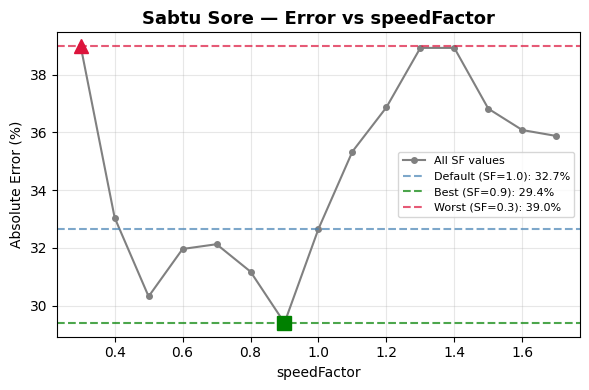

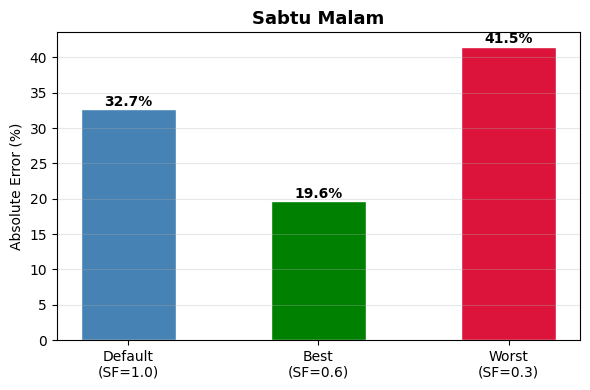

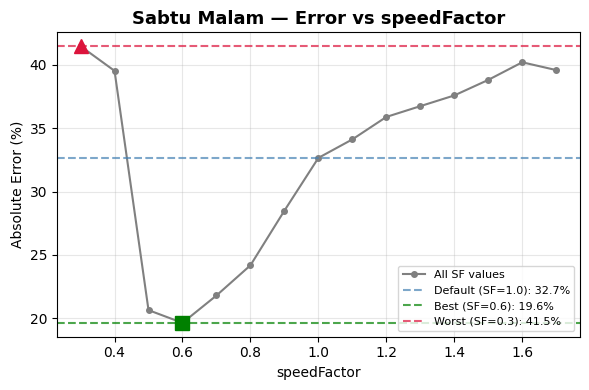

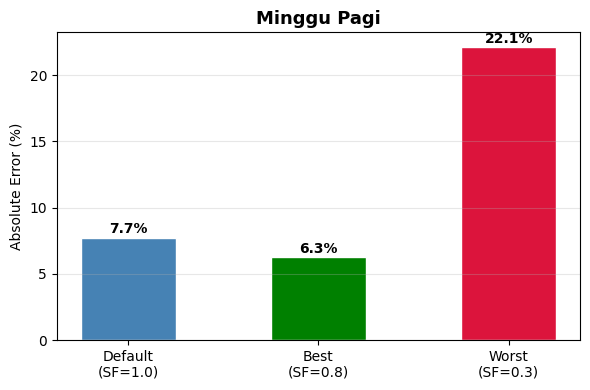

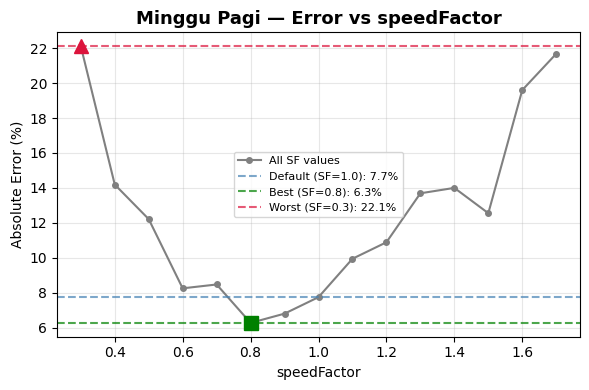

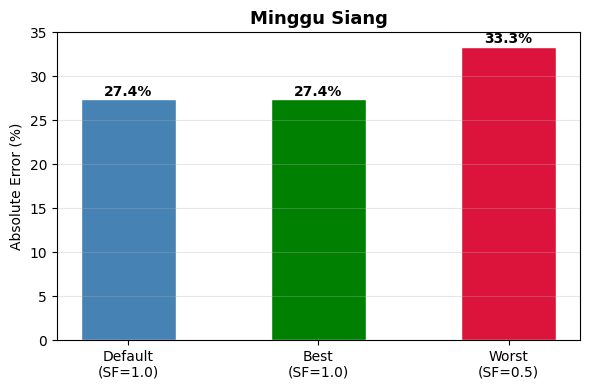

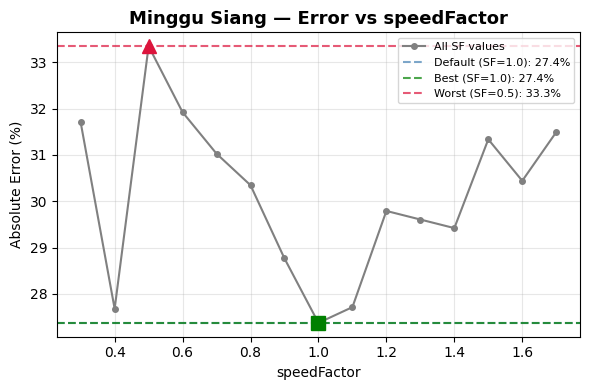

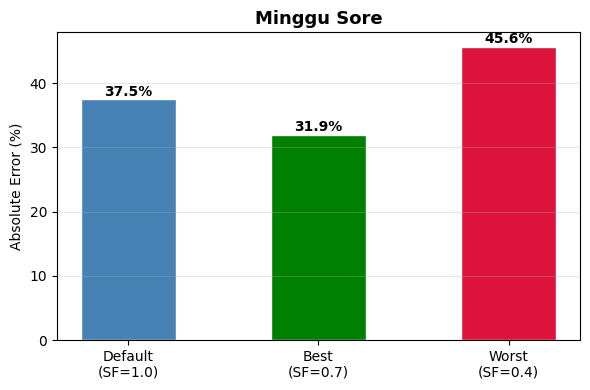

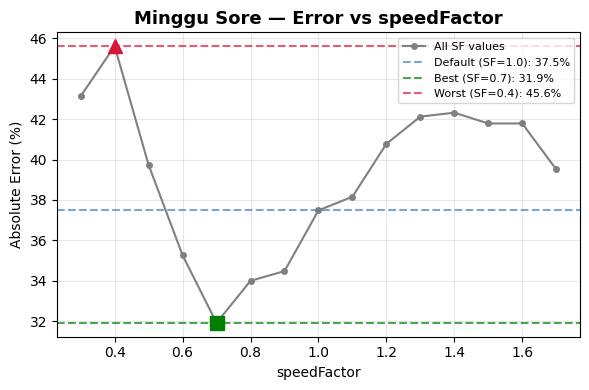

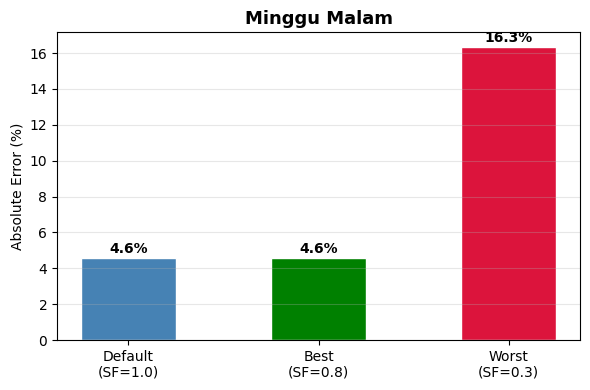

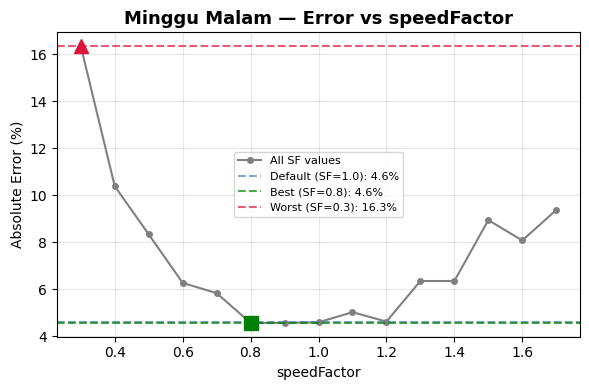

In [4]:
for label in df["data_label"].unique():
    subset = df[df["data_label"] == label].copy()
    default_row = subset[subset["speedFactor"] == 1.0]
    if default_row.empty:
        continue

    default_err = default_row["abs_error"].values[0]
    min_err = subset["abs_error"].min()
    max_err = subset["abs_error"].max()
    best_sf = subset.loc[subset["abs_error"].idxmin(), "speedFactor"]
    worst_sf = subset.loc[subset["abs_error"].idxmax(), "speedFactor"]

    # --- Chart 1: Default vs Best vs Worst bar chart ---
    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(
        ["Default\n(SF=1.0)", f"Best\n(SF={best_sf})", f"Worst\n(SF={worst_sf})"],
        [default_err, min_err, max_err],
        color=["steelblue", "green", "crimson"],
        edgecolor="white", width=0.5,
    )
    for bar, val in zip(bars, [default_err, min_err, max_err]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_ylabel("Absolute Error (%)")
    ax.set_title(f"{label}", fontsize=13, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Chart 2: Error curve across all speedFactor values ---
    fig, ax = plt.subplots(figsize=(6, 4))
    subset_sorted = subset.sort_values("speedFactor")
    ax.plot(subset_sorted["speedFactor"], subset_sorted["abs_error"],
            "o-", color="gray", markersize=4, label="All SF values")
    ax.axhline(y=default_err, color="steelblue", linestyle="--", alpha=0.7,
               label=f"Default (SF=1.0): {default_err:.1f}%")
    ax.axhline(y=min_err, color="green", linestyle="--", alpha=0.7,
               label=f"Best (SF={best_sf}): {min_err:.1f}%")
    ax.axhline(y=max_err, color="crimson", linestyle="--", alpha=0.7,
               label=f"Worst (SF={worst_sf}): {max_err:.1f}%")
    ax.plot(best_sf, min_err, "s", color="green", markersize=10, zorder=5)
    ax.plot(worst_sf, max_err, "^", color="crimson", markersize=10, zorder=5)
    ax.set_xlabel("speedFactor")
    ax.set_ylabel("Absolute Error (%)")
    ax.set_title(f"{label} — Error vs speedFactor", fontsize=13, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Summary Statistics

In [5]:
summary_rows = []
for label in df["data_label"].unique():
    subset = df[df["data_label"] == label]
    default_row = subset[subset["speedFactor"] == 1.0]
    if default_row.empty:
        continue
    summary_rows.append({
        "label": label,
        "default_error": default_row["abs_error"].values[0],
        "min_error": subset["abs_error"].min(),
        "max_error": subset["abs_error"].max(),
        "best_sf": subset.loc[subset["abs_error"].idxmin(), "speedFactor"],
        "worst_sf": subset.loc[subset["abs_error"].idxmax(), "speedFactor"],
    })

summary = pd.DataFrame(summary_rows)
summary["improvement"] = summary["default_error"] - summary["min_error"]

print("Across all data points:")
print(f"  Default (SF=1.0) avg error: {summary['default_error'].mean():.2f}%")
print(f"  Best-case avg error:         {summary['min_error'].mean():.2f}%")
print(f"  Worst-case avg error:        {summary['max_error'].mean():.2f}%")
print(f"  Avg improvement (def - best): {summary['improvement'].mean():.2f}%")
print()
print("Most impacted data point:")
most = summary.loc[summary["improvement"].idxmax()]
print(f"  {most['label']}: {most['improvement']:.2f}% reduction (SF={most['best_sf']})")
print()
print("Least impacted data point:")
least = summary.loc[summary["improvement"].idxmin()]
print(f"  {least['label']}: {least['improvement']:.2f}% reduction (SF={least['best_sf']})")

Across all data points:
  Default (SF=1.0) avg error: 19.86%
  Best-case avg error:         15.57%
  Worst-case avg error:        29.52%
  Avg improvement (def - best): 4.30%

Most impacted data point:
  Sabtu Malam: 13.01% reduction (SF=0.6)

Least impacted data point:
  Senin Pagi: 0.00% reduction (SF=1.0)
